Purpose: Test whether relationships among our engineered metrics behave in ways that are economically coherent, and identify redundancy or unexpected relationships before we use the metrics for credit-risk decisions.

In [1]:
import pandas as pd 
import duckdb 

In [2]:
import plotly.express as px

In [3]:
from scipy.stats import spearmanr, pearsonr

In [4]:
conn=duckdb.connect(r"D:\SEC.gov project\database\credit_risk.db")

1. Liquidity Hierarchy

a. CR-QR Correlation

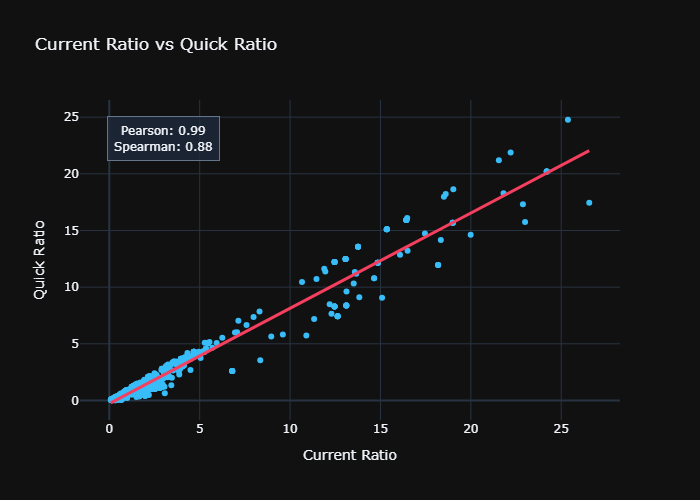

In [5]:
df = conn.sql("""
    SELECT
        accession_number,
        period_end,
        current_ratio,
        quick_ratio
    FROM gold.fact_financial_metrics
    WHERE current_ratio IS NOT NULL
      AND quick_ratio IS NOT NULL
""").df()

pearson_corr, pearson_p = pearsonr(df['current_ratio'], df['quick_ratio'])
spearman_corr, spearman_p = spearmanr(df['current_ratio'], df['quick_ratio'])

cr_low, cr_high = df["current_ratio"].quantile([0.01, 0.99])
qr_low, qr_high = df["quick_ratio"].quantile([0.01, 0.99])

df_plot = df[
    df["current_ratio"].between(cr_low, cr_high)
    & df["quick_ratio"].between(qr_low, qr_high)
]

fig = px.scatter(
    df_plot,
    x="current_ratio",
    y="quick_ratio",
    title="Current Ratio vs Quick Ratio",
    labels={"current_ratio": "Current Ratio", "quick_ratio": "Quick Ratio"},
    trendline="ols",
    template="plotly_dark",
    color_discrete_sequence=["#38BDF8"]  
)

fig.update_traces(line=dict(color="#F43F5E", width=3), selector=dict(mode="lines"))

fig.add_annotation(
    x=0.05,
    y=0.95,
    xref="paper",
    yref="paper",
    text=f'Pearson: {pearson_corr:.2f}<br>Spearman: {spearman_corr:.2f}',
    showarrow=False,
    bgcolor="rgba(30, 41, 59, 0.8)", 
    bordercolor="#64748B",            
    borderwidth=1,
    borderpad=6
)

fig.show(renderer="png")

Current Ratio and Quick Ratio show the expected strong positive relationship, supporting their financial consistency and allowing them to be jointly used in subsequent liquidity analysis.

b. QR-Cash Ratio

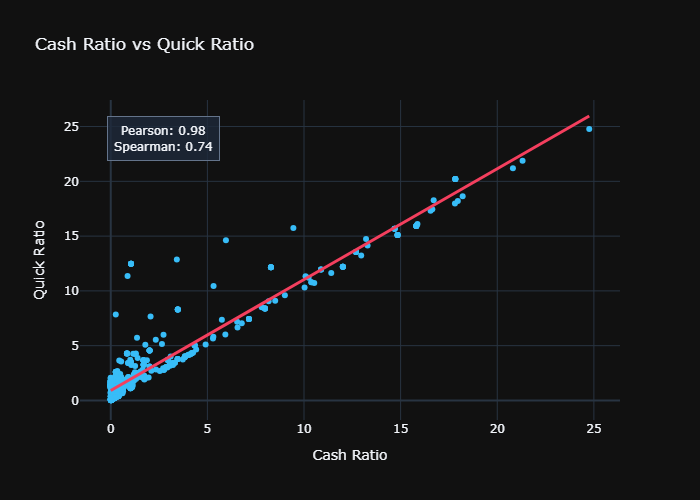

In [6]:
df = conn.sql("""
    SELECT
        accession_number,
        period_end,
        cash_ratio,
        quick_ratio
    FROM gold.fact_financial_metrics
    WHERE cash_ratio IS NOT NULL
      AND quick_ratio IS NOT NULL
""").df()

pearson_corr, pearson_p = pearsonr(df['cash_ratio'], df['quick_ratio'])
spearman_corr, spearman_p = spearmanr(df['cash_ratio'], df['quick_ratio'])

cr_low, cr_high = df["cash_ratio"].quantile([0.01, 0.99])
qr_low, qr_high = df["quick_ratio"].quantile([0.01, 0.99])

df_plot = df[
    df["cash_ratio"].between(cr_low, cr_high)
    & df["quick_ratio"].between(qr_low, qr_high)
]

fig = px.scatter(
    df_plot,
    x="cash_ratio",
    y="quick_ratio",
    title="Cash Ratio vs Quick Ratio",
    labels={"cash_ratio": "Cash Ratio", "quick_ratio": "Quick Ratio"},
    trendline="ols",
    template="plotly_dark",
    color_discrete_sequence=["#38BDF8"]  
)

fig.update_traces(line=dict(color="#F43F5E", width=3), selector=dict(mode="lines"))

fig.add_annotation(
    x=0.05,
    y=0.95,
    xref="paper",
    yref="paper",
    text=f'Pearson: {pearson_corr:.2f}<br>Spearman: {spearman_corr:.2f}',
    showarrow=False,
    bgcolor="rgba(30, 41, 59, 0.8)", 
    bordercolor="#64748B",            
    borderwidth=1,
    borderpad=6
)

fig.show(renderer="png")

Cash Ratio and Quick Ratio show a strong positive relationship (Pearson = 0.98; Spearman = 0.74), broadly aligning with the expected liquidity hierarchy and supporting their joint use in subsequent liquidity analysis.

c. CR-Cash Ratio

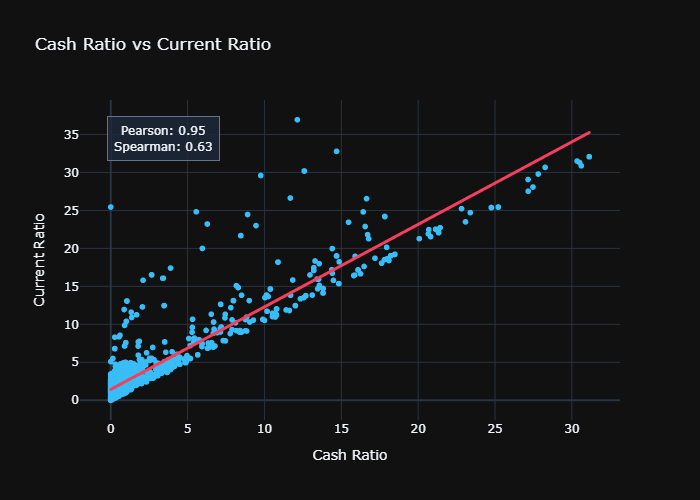

In [7]:
df = conn.sql("""
    SELECT
        accession_number,
        period_end,
        cash_ratio,
        current_ratio
    FROM gold.fact_financial_metrics
    WHERE cash_ratio IS NOT NULL
      AND current_ratio IS NOT NULL
""").df()

pearson_corr, pearson_p = pearsonr(df['cash_ratio'], df['current_ratio'])
spearman_corr, spearman_p = spearmanr(df['cash_ratio'], df['current_ratio'])

cr_low, cr_high = df["cash_ratio"].quantile([0.01, 0.99])
qr_low, qr_high = df["current_ratio"].quantile([0.01, 0.99])

df_plot = df[
    df["cash_ratio"].between(cr_low, cr_high)
    & df["current_ratio"].between(qr_low, qr_high)
]

fig = px.scatter(
    df_plot,
    x="cash_ratio",
    y="current_ratio",
    title="Cash Ratio vs Current Ratio",
    labels={"cash_ratio": "Cash Ratio", "current_ratio": "Current Ratio"},
    trendline="ols",
    template="plotly_dark",
    color_discrete_sequence=["#38BDF8"]  
)

fig.update_traces(line=dict(color="#F43F5E", width=3), selector=dict(mode="lines"))

fig.add_annotation(
    x=0.05,
    y=0.95,
    xref="paper",
    yref="paper",
    text=f'Pearson: {pearson_corr:.2f}<br>Spearman: {spearman_corr:.2f}',
    showarrow=False,
    bgcolor="rgba(30, 41, 59, 0.8)", 
    bordercolor="#64748B",            
    borderwidth=1,
    borderpad=6
)

fig.show(renderer="png")

The three liquidity ratios exhibit the expected positive relationships across the liquidity hierarchy, with strongest association between adjacent measures; this supports the internal consistency of the liquidity metrics for subsequent analysis.

2. Leverage vs Repayment Capacity

a. Debt/Assets-ICR

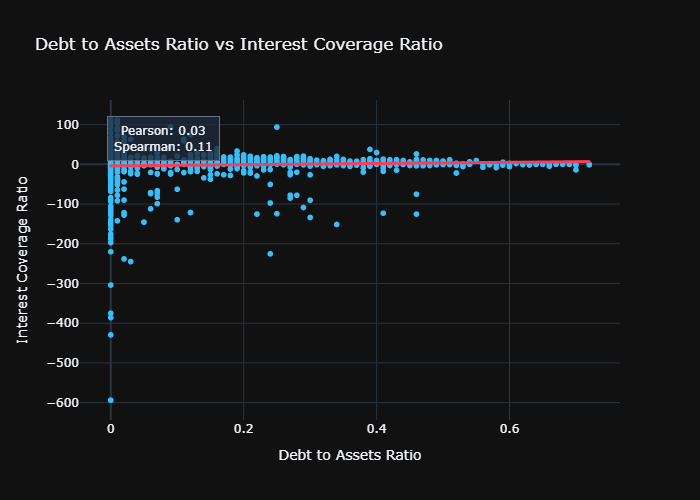

In [8]:
df = conn.sql("""
    SELECT
        accession_number,
        period_end,
        debt_to_assets_ratio,
        interest_coverage_ratio
    FROM gold.fact_financial_metrics
    WHERE debt_to_assets_ratio IS NOT NULL
      AND interest_coverage_ratio IS NOT NULL
""").df()

pearson_corr, pearson_p = pearsonr(df['debt_to_assets_ratio'], df['interest_coverage_ratio'])
spearman_corr, spearman_p = spearmanr(df['debt_to_assets_ratio'], df['interest_coverage_ratio'])

da_low, da_high = df["debt_to_assets_ratio"].quantile([0.01, 0.99])
ic_low, ic_high = df["interest_coverage_ratio"].quantile([0.01, 0.99])

df_plot = df[
    df["debt_to_assets_ratio"].between(da_low, da_high)
    & df["interest_coverage_ratio"].between(ic_low, ic_high)
]

fig = px.scatter(
    df_plot,
    x="debt_to_assets_ratio",
    y="interest_coverage_ratio",
    title="Debt to Assets Ratio vs Interest Coverage Ratio",
    labels={"debt_to_assets_ratio": "Debt to Assets Ratio", "interest_coverage_ratio": "Interest Coverage Ratio"},
    trendline="ols",
    template="plotly_dark",
    color_discrete_sequence=["#38BDF8"]  
)

fig.update_traces(line=dict(color="#F43F5E", width=3), selector=dict(mode="lines"))

fig.add_annotation(
    x=0.05,
    y=0.95,
    xref="paper",
    yref="paper",
    text=f'Pearson: {pearson_corr:.2f}<br>Spearman: {spearman_corr:.2f}',
    showarrow=False,
    bgcolor="rgba(30, 41, 59, 0.8)", 
    bordercolor="#64748B",            
    borderwidth=1,
    borderpad=6
)

fig.show(renderer="png")

Debt-to-assets ratio and ICR exhibit negligible correlation in the analytical population (Pearson = 0.03; Spearman = 0.11), with no clear inverse pattern. This does not indicate a calculation anomaly because the metrics capture different dimensions of financial risk and ICR is strongly influenced by operating profitability and interest expense. Both metrics are therefore retained as independent indicators for subsequent credit-risk analysis.

b. Debt/Assets-OCF/Debt

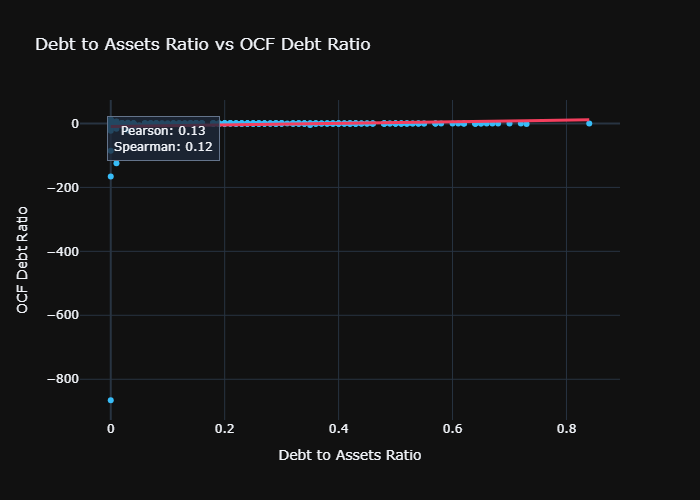

In [9]:
df = conn.sql("""
    SELECT
        accession_number,
        period_end,
        debt_to_assets_ratio,
        ocf_debt_ratio	
    FROM gold.fact_financial_metrics
    WHERE debt_to_assets_ratio IS NOT NULL
      AND ocf_debt_ratio IS NOT NULL
""").df()

pearson_corr, pearson_p = pearsonr(df['debt_to_assets_ratio'], df['ocf_debt_ratio'])
spearman_corr, spearman_p = spearmanr(df['debt_to_assets_ratio'], df['ocf_debt_ratio'])

da_low, da_high = df["debt_to_assets_ratio"].quantile([0.01, 0.99])
ocf_low, ocf_high = df["ocf_debt_ratio"].quantile([0.01, 0.99])

df_plot = df[
    df["debt_to_assets_ratio"].between(da_low, da_high)
    & df["ocf_debt_ratio"].between(ocf_low, ocf_high)
]

fig = px.scatter(
    df_plot,
    x="debt_to_assets_ratio",
    y="ocf_debt_ratio",
    title="Debt to Assets Ratio vs OCF Debt Ratio",
    labels={"debt_to_assets_ratio": "Debt to Assets Ratio", "ocf_debt_ratio": "OCF Debt Ratio"},
    trendline="ols",
    template="plotly_dark",
    color_discrete_sequence=["#38BDF8"]  
)

fig.update_traces(line=dict(color="#F43F5E", width=3), selector=dict(mode="lines"))

fig.add_annotation(
    x=0.05,
    y=0.95,
    xref="paper",
    yref="paper",
    text=f'Pearson: {pearson_corr:.2f}<br>Spearman: {spearman_corr:.2f}',
    showarrow=False,
    bgcolor="rgba(30, 41, 59, 0.8)", 
    bordercolor="#64748B",            
    borderwidth=1,
    borderpad=6
)

fig.show(renderer="png")

c. Debt/Assets-FCF/Debt

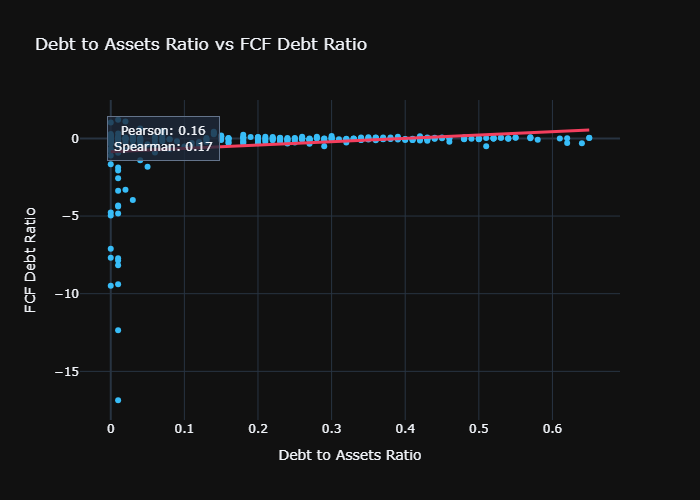

In [10]:
df = conn.sql("""
    SELECT
        accession_number,
        period_end,
        debt_to_assets_ratio,
        fcf_to_debt_ratio	
    FROM gold.fact_financial_metrics
    WHERE debt_to_assets_ratio IS NOT NULL
      AND fcf_to_debt_ratio IS NOT NULL
""").df()

pearson_corr, pearson_p = pearsonr(df['debt_to_assets_ratio'], df['fcf_to_debt_ratio'])
spearman_corr, spearman_p = spearmanr(df['debt_to_assets_ratio'], df['fcf_to_debt_ratio'])

da_low, da_high = df["debt_to_assets_ratio"].quantile([0.01, 0.99])
fcf_low, fcf_high = df["fcf_to_debt_ratio"].quantile([0.01, 0.99])

df_plot = df[
    df["debt_to_assets_ratio"].between(da_low, da_high)
    & df["fcf_to_debt_ratio"].between(fcf_low, fcf_high)
]

fig = px.scatter(
    df_plot,
    x="debt_to_assets_ratio",
    y="fcf_to_debt_ratio",
    title="Debt to Assets Ratio vs FCF Debt Ratio",
    labels={"debt_to_assets_ratio": "Debt to Assets Ratio", "fcf_to_debt_ratio": "FCF Debt Ratio"},
    trendline="ols",
    template="plotly_dark",
    color_discrete_sequence=["#38BDF8"]  
)

fig.update_traces(line=dict(color="#F43F5E", width=3), selector=dict(mode="lines"))

fig.add_annotation(
    x=0.05,
    y=0.95,
    xref="paper",
    yref="paper",
    text=f'Pearson: {pearson_corr:.2f}<br>Spearman: {spearman_corr:.2f}',
    showarrow=False,
    bgcolor="rgba(30, 41, 59, 0.8)", 
    bordercolor="#64748B",            
    borderwidth=1,
    borderpad=6
)

fig.show(renderer="png")

The financial condition represented by these metrics is multidimensional in this population.

3. Earnings vs cash repayment 

a. ICR-OCF/Debt 

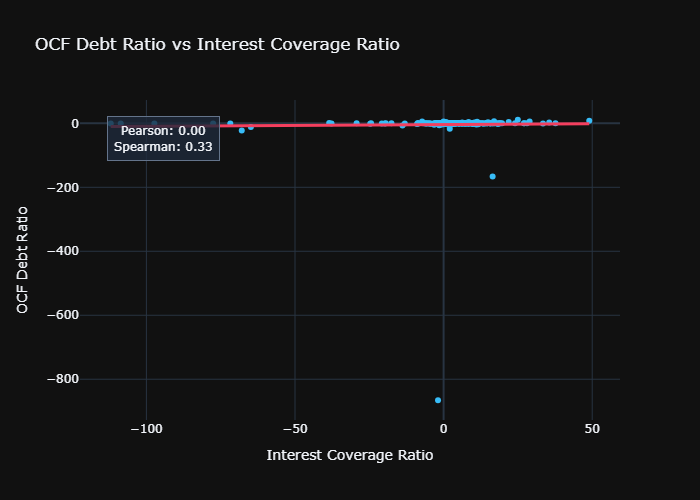

In [11]:
df = conn.sql("""
    SELECT
        accession_number,
        period_end,
        ocf_debt_ratio,
        interest_coverage_ratio
    FROM gold.fact_financial_metrics
    WHERE ocf_debt_ratio IS NOT NULL
      AND interest_coverage_ratio IS NOT NULL
""").df()

pearson_corr, pearson_p = pearsonr(df['ocf_debt_ratio'], df['interest_coverage_ratio'])
spearman_corr, spearman_p = spearmanr(df['ocf_debt_ratio'], df['interest_coverage_ratio'])

ocf_low, ocf_high = df["ocf_debt_ratio"].quantile([0.01, 0.99])
ic_low, ic_high = df["interest_coverage_ratio"].quantile([0.01, 0.99])

df_plot = df[
    df["ocf_debt_ratio"].between(ocf_low, ocf_high)
    & df["interest_coverage_ratio"].between(ic_low, ic_high)
]

fig = px.scatter(
    df_plot,
    x="interest_coverage_ratio",
    y="ocf_debt_ratio",
    title="OCF Debt Ratio vs Interest Coverage Ratio",
    labels={"ocf_debt_ratio": "OCF Debt Ratio", "interest_coverage_ratio": "Interest Coverage Ratio"},
    trendline="ols",
    template="plotly_dark",
    color_discrete_sequence=["#38BDF8"]  
)

fig.update_traces(line=dict(color="#F43F5E", width=3), selector=dict(mode="lines"))

fig.add_annotation(
    x=0.05,
    y=0.95,
    xref="paper",
    yref="paper",
    text=f'Pearson: {pearson_corr:.2f}<br>Spearman: {spearman_corr:.2f}',
    showarrow=False,
    bgcolor="rgba(30, 41, 59, 0.8)", 
    bordercolor="#64748B",            
    borderwidth=1,
    borderpad=6
)

fig.show(renderer="png")

b. ICR-FCF/Debt

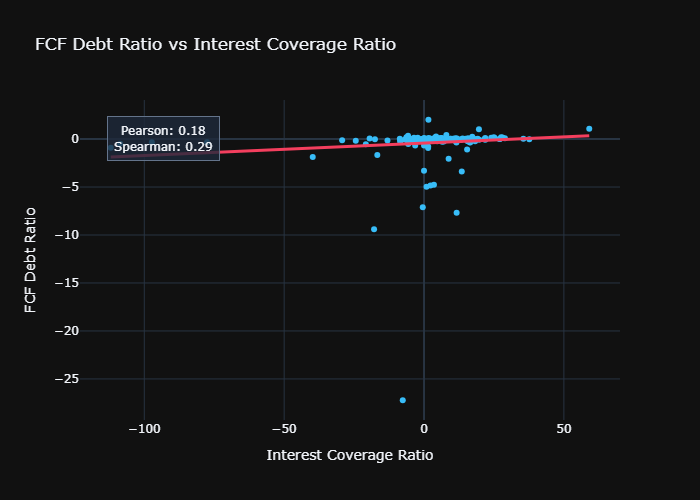

In [12]:
df = conn.sql("""
    SELECT
        accession_number,
        period_end,
        fcf_to_debt_ratio,
        interest_coverage_ratio
    FROM gold.fact_financial_metrics
    WHERE fcf_to_debt_ratio IS NOT NULL
      AND interest_coverage_ratio IS NOT NULL
""").df()

pearson_corr, pearson_p = pearsonr(df['fcf_to_debt_ratio'], df['interest_coverage_ratio'])
spearman_corr, spearman_p = spearmanr(df['fcf_to_debt_ratio'], df['interest_coverage_ratio'])

fcf_low, fcf_high = df["fcf_to_debt_ratio"].quantile([0.01, 0.99])
ic_low, ic_high = df["interest_coverage_ratio"].quantile([0.01, 0.99])

df_plot = df[
    df["fcf_to_debt_ratio"].between(fcf_low, fcf_high)
    & df["interest_coverage_ratio"].between(ic_low, ic_high)
]

fig = px.scatter(
    df_plot,
    x="interest_coverage_ratio",
    y="fcf_to_debt_ratio",
    title="FCF Debt Ratio vs Interest Coverage Ratio",
    labels={"fcf_to_debt_ratio": "FCF Debt Ratio", "interest_coverage_ratio": "Interest Coverage Ratio"},
    trendline="ols",
    template="plotly_dark",
    color_discrete_sequence=["#38BDF8"]  
)

fig.update_traces(line=dict(color="#F43F5E", width=3), selector=dict(mode="lines"))

fig.add_annotation(
    x=0.05,
    y=0.95,
    xref="paper",
    yref="paper",
    text=f'Pearson: {pearson_corr:.2f}<br>Spearman: {spearman_corr:.2f}',
    showarrow=False,
    bgcolor="rgba(30, 41, 59, 0.8)", 
    bordercolor="#64748B",            
    borderwidth=1,
    borderpad=6
)

fig.show(renderer="png")

c. OCF/Debt-FCF/Debt

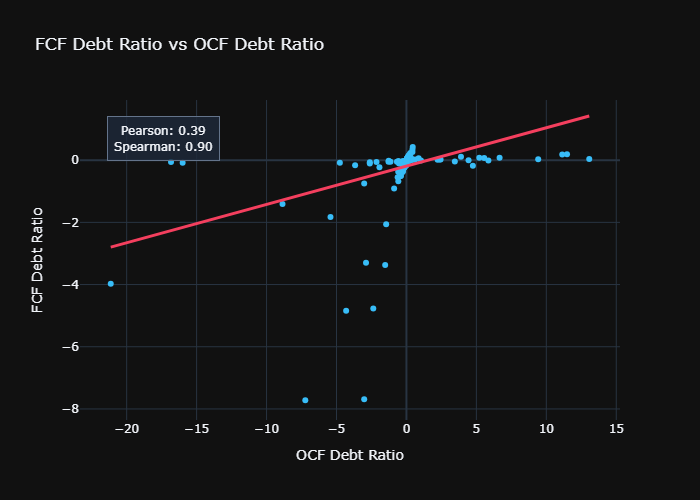

In [13]:
df = conn.sql("""
    SELECT
        accession_number,
        period_end,
        fcf_to_debt_ratio,
        ocf_debt_ratio
    FROM gold.fact_financial_metrics
    WHERE fcf_to_debt_ratio IS NOT NULL
      AND ocf_debt_ratio IS NOT NULL
""").df()

pearson_corr, pearson_p = pearsonr(df['fcf_to_debt_ratio'], df['ocf_debt_ratio'])
spearman_corr, spearman_p = spearmanr(df['fcf_to_debt_ratio'], df['ocf_debt_ratio'])

fcf_low, fcf_high = df["fcf_to_debt_ratio"].quantile([0.01, 0.99])
ocf_low, ocf_high = df["ocf_debt_ratio"].quantile([0.01, 0.99])

df_plot = df[
    df["fcf_to_debt_ratio"].between(fcf_low, fcf_high)
    & df["ocf_debt_ratio"].between(ocf_low, ocf_high)
]

fig = px.scatter(
    df_plot,
    x="ocf_debt_ratio",
    y="fcf_to_debt_ratio",
    title="FCF Debt Ratio vs OCF Debt Ratio",
    labels={"fcf_to_debt_ratio": "FCF Debt Ratio", "ocf_debt_ratio": "OCF Debt Ratio"},
    trendline="ols",
    template="plotly_dark",
    color_discrete_sequence=["#38BDF8"]  
)

fig.update_traces(line=dict(color="#F43F5E", width=3), selector=dict(mode="lines"))

fig.add_annotation(
    x=0.05,
    y=0.95,
    xref="paper",
    yref="paper",
    text=f'Pearson: {pearson_corr:.2f}<br>Spearman: {spearman_corr:.2f}',
    showarrow=False,
    bgcolor="rgba(30, 41, 59, 0.8)", 
    bordercolor="#64748B",            
    borderwidth=1,
    borderpad=6
)

fig.show(renderer="png")

4. Profitability vs cash generation

a. ROA-Cash Earnings Conversion

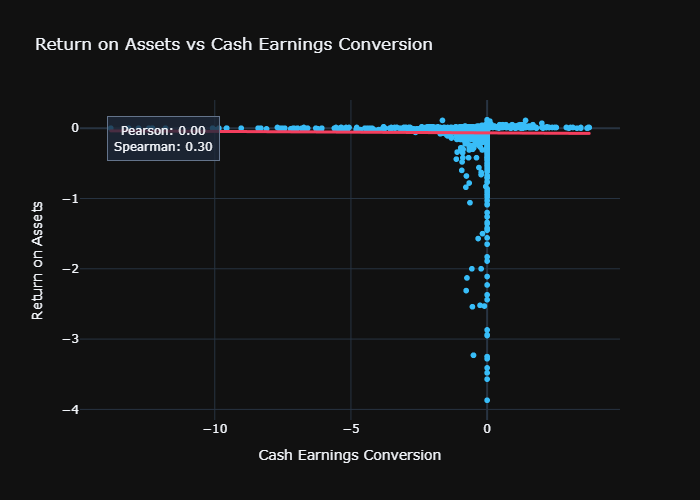

In [14]:
df = conn.sql("""
    SELECT
        accession_number,
        period_end,
        return_on_assets,
        cash_earnings_conversion
    FROM gold.fact_financial_metrics
    WHERE return_on_assets IS NOT NULL
      AND cash_earnings_conversion IS NOT NULL
""").df()

pearson_corr, pearson_p = pearsonr(df['return_on_assets'], df['cash_earnings_conversion'])
spearman_corr, spearman_p = spearmanr(df['return_on_assets'], df['cash_earnings_conversion'])

roa_low, roa_high = df["return_on_assets"].quantile([0.01, 0.99])
cec_low, cec_high = df["cash_earnings_conversion"].quantile([0.01, 0.99])

df_plot = df[
    df["return_on_assets"].between(roa_low, roa_high)
    & df["cash_earnings_conversion"].between(cec_low, cec_high)
]

fig = px.scatter(
    df_plot,
    x="cash_earnings_conversion",
    y="return_on_assets",
    title="Return on Assets vs Cash Earnings Conversion",
    labels={"return_on_assets": "Return on Assets", "cash_earnings_conversion": "Cash Earnings Conversion"},
    trendline="ols",
    template="plotly_dark",
    color_discrete_sequence=["#38BDF8"]  
)

fig.update_traces(line=dict(color="#F43F5E", width=3), selector=dict(mode="lines"))

fig.add_annotation(
    x=0.05,
    y=0.95,
    xref="paper",
    yref="paper",
    text=f'Pearson: {pearson_corr:.2f}<br>Spearman: {spearman_corr:.2f}',
    showarrow=False,
    bgcolor="rgba(30, 41, 59, 0.8)", 
    bordercolor="#64748B",            
    borderwidth=1,
    borderpad=6
)

fig.show(renderer="png")

b. ROA-OCF/Debt

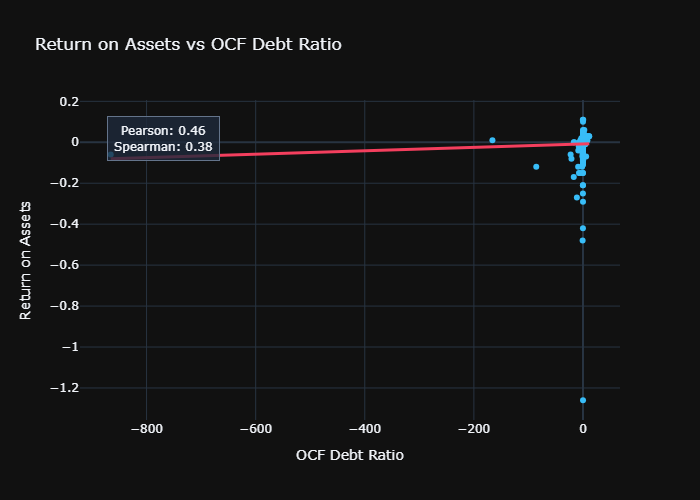

In [15]:
df = conn.sql("""
    SELECT
        accession_number,
        period_end,
        return_on_assets,
        ocf_debt_ratio
    FROM gold.fact_financial_metrics
    WHERE return_on_assets IS NOT NULL
      AND ocf_debt_ratio IS NOT NULL
""").df()

pearson_corr, pearson_p = pearsonr(df['return_on_assets'], df['ocf_debt_ratio'])
spearman_corr, spearman_p = spearmanr(df['return_on_assets'], df['ocf_debt_ratio'])

roa_low, roa_high = df["return_on_assets"].quantile([0.01, 0.99])
ocr_low, ocr_high = df["ocf_debt_ratio"].quantile([0.01, 0.99])

df_plot = df[
    df["return_on_assets"].between(roa_low, roa_high)
    & df["ocf_debt_ratio"].between(ocr_low, ocr_high)
]

fig = px.scatter(
    df_plot,
    x="ocf_debt_ratio",
    y="return_on_assets",
    title="Return on Assets vs OCF Debt Ratio",
    labels={"return_on_assets": "Return on Assets", "ocf_debt_ratio": "OCF Debt Ratio"},
    trendline="ols",
    template="plotly_dark",
    color_discrete_sequence=["#38BDF8"]  
)

fig.update_traces(line=dict(color="#F43F5E", width=3), selector=dict(mode="lines"))

fig.add_annotation(
    x=0.05,
    y=0.95,
    xref="paper",
    yref="paper",
    text=f'Pearson: {pearson_corr:.2f}<br>Spearman: {spearman_corr:.2f}',
    showarrow=False,
    bgcolor="rgba(30, 41, 59, 0.8)", 
    bordercolor="#64748B",            
    borderwidth=1,
    borderpad=6
)

fig.show(renderer="png")

c. ROA-FCF/Debt

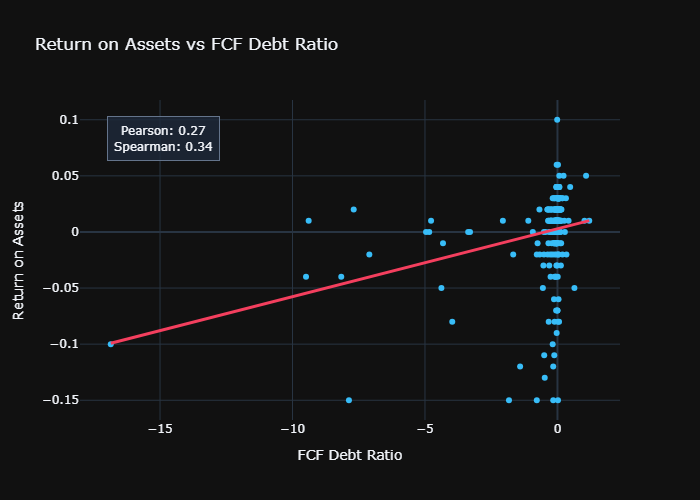

In [16]:
df = conn.sql("""
    SELECT
        accession_number,
        period_end,
        return_on_assets,
        fcf_to_debt_ratio
    FROM gold.fact_financial_metrics
    WHERE return_on_assets IS NOT NULL
      AND fcf_to_debt_ratio IS NOT NULL
""").df()

pearson_corr, pearson_p = pearsonr(df['return_on_assets'], df['fcf_to_debt_ratio'])
spearman_corr, spearman_p = spearmanr(df['return_on_assets'], df['fcf_to_debt_ratio'])

roa_low, roa_high = df["return_on_assets"].quantile([0.01, 0.99])
fcr_low, fcr_high = df["fcf_to_debt_ratio"].quantile([0.01, 0.99])

df_plot = df[
    df["return_on_assets"].between(roa_low, roa_high)
    & df["fcf_to_debt_ratio"].between(fcr_low, fcr_high)
]

fig = px.scatter(
    df_plot,
    x="fcf_to_debt_ratio",
    y="return_on_assets",
    title="Return on Assets vs FCF Debt Ratio",
    labels={"return_on_assets": "Return on Assets", "fcf_to_debt_ratio": "FCF Debt Ratio"},
    trendline="ols",
    template="plotly_dark",
    color_discrete_sequence=["#38BDF8"]  
)

fig.update_traces(line=dict(color="#F43F5E", width=3), selector=dict(mode="lines"))

fig.add_annotation(
    x=0.05,
    y=0.95,
    xref="paper",
    yref="paper",
    text=f'Pearson: {pearson_corr:.2f}<br>Spearman: {spearman_corr:.2f}',
    showarrow=False,
    bgcolor="rgba(30, 41, 59, 0.8)", 
    bordercolor="#64748B",            
    borderwidth=1,
    borderpad=6
)

fig.show(renderer="png")

5. Refinancing pressure

a. Short-Term Debt Ratio-Cash Ratio

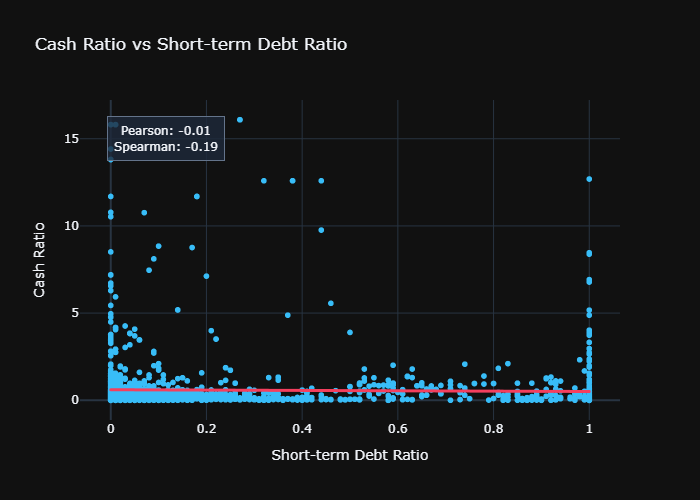

In [17]:
df = conn.sql("""
    SELECT
        accession_number,
        period_end,
        short_term_debt_ratio,
        cash_ratio	
    FROM gold.fact_financial_metrics
    WHERE short_term_debt_ratio IS NOT NULL
      AND cash_ratio IS NOT NULL
""").df()

pearson_corr, pearson_p = pearsonr(df['short_term_debt_ratio'], df['cash_ratio'])
spearman_corr, spearman_p = spearmanr(df['short_term_debt_ratio'], df['cash_ratio'])

roa_low, roa_high = df["short_term_debt_ratio"].quantile([0.01, 0.99])
fcr_low, fcr_high = df["cash_ratio"].quantile([0.01, 0.99])

df_plot = df[
    df["short_term_debt_ratio"].between(roa_low, roa_high)
    & df["cash_ratio"].between(fcr_low, fcr_high)
]

fig = px.scatter(
    df_plot,
    x="short_term_debt_ratio",
    y="cash_ratio",
    title="Cash Ratio vs Short-term Debt Ratio",
    labels={"short_term_debt_ratio": "Short-term Debt Ratio", "cash_ratio": "Cash Ratio"},
    trendline="ols",
    template="plotly_dark",
    color_discrete_sequence=["#38BDF8"]  
)

fig.update_traces(line=dict(color="#F43F5E", width=3), selector=dict(mode="lines"))

fig.add_annotation(
    x=0.05,
    y=0.95,
    xref="paper",
    yref="paper",
    text=f'Pearson: {pearson_corr:.2f}<br>Spearman: {spearman_corr:.2f}',
    showarrow=False,
    bgcolor="rgba(30, 41, 59, 0.8)", 
    bordercolor="#64748B",            
    borderwidth=1,
    borderpad=6
)

fig.show(renderer="png")

b. Short-Term Debt Ratio-OCF/Debt

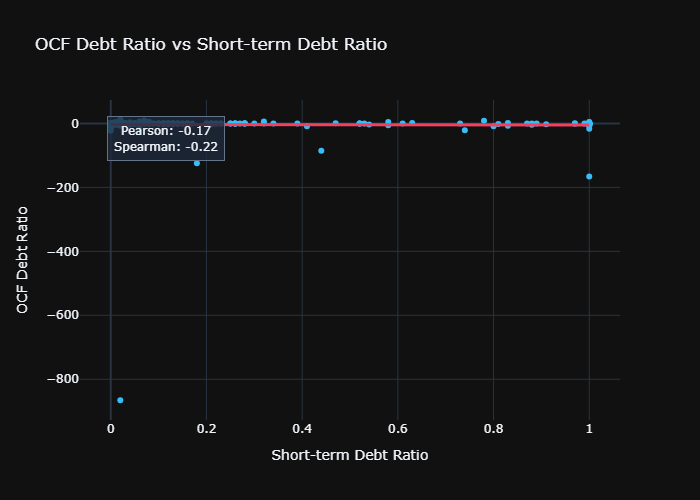

In [18]:
df = conn.sql("""
    SELECT
        accession_number,
        period_end,
        short_term_debt_ratio,
        ocf_debt_ratio		
    FROM gold.fact_financial_metrics
    WHERE short_term_debt_ratio IS NOT NULL
      AND ocf_debt_ratio IS NOT NULL
""").df()

pearson_corr, pearson_p = pearsonr(df['short_term_debt_ratio'], df['ocf_debt_ratio'])
spearman_corr, spearman_p = spearmanr(df['short_term_debt_ratio'], df['ocf_debt_ratio'])

roa_low, roa_high = df["short_term_debt_ratio"].quantile([0.01, 0.99])
fcr_low, fcr_high = df["ocf_debt_ratio"].quantile([0.01, 0.99])

df_plot = df[
    df["short_term_debt_ratio"].between(roa_low, roa_high)
    & df["ocf_debt_ratio"].between(fcr_low, fcr_high)
]

fig = px.scatter(
    df_plot,
    x="short_term_debt_ratio",
    y="ocf_debt_ratio",
    title="OCF Debt Ratio vs Short-term Debt Ratio",
    labels={"short_term_debt_ratio": "Short-term Debt Ratio", "ocf_debt_ratio": "OCF Debt Ratio"},
    trendline="ols",
    template="plotly_dark",
    color_discrete_sequence=["#38BDF8"]  
)

fig.update_traces(line=dict(color="#F43F5E", width=3), selector=dict(mode="lines"))

fig.add_annotation(
    x=0.05,
    y=0.95,
    xref="paper",
    yref="paper",
    text=f'Pearson: {pearson_corr:.2f}<br>Spearman: {spearman_corr:.2f}',
    showarrow=False,
    bgcolor="rgba(30, 41, 59, 0.8)", 
    bordercolor="#64748B",            
    borderwidth=1,
    borderpad=6
)

fig.show(renderer="png")

c. Short-Term Debt Ratio-FCF/Debt

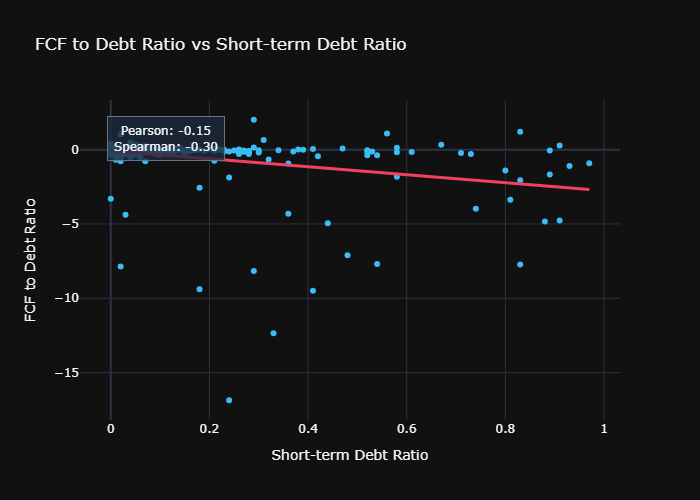

In [19]:
df = conn.sql("""
    SELECT
        accession_number,
        period_end,
        short_term_debt_ratio,
        fcf_to_debt_ratio		
    FROM gold.fact_financial_metrics
    WHERE short_term_debt_ratio IS NOT NULL
      AND fcf_to_debt_ratio IS NOT NULL
""").df()

pearson_corr, pearson_p = pearsonr(df['short_term_debt_ratio'], df['fcf_to_debt_ratio'])
spearman_corr, spearman_p = spearmanr(df['short_term_debt_ratio'], df['fcf_to_debt_ratio'])

roa_low, roa_high = df["short_term_debt_ratio"].quantile([0.01, 0.99])
fcr_low, fcr_high = df["fcf_to_debt_ratio"].quantile([0.01, 0.99])

df_plot = df[
    df["short_term_debt_ratio"].between(roa_low, roa_high)
    & df["fcf_to_debt_ratio"].between(fcr_low, fcr_high)
]

fig = px.scatter(
    df_plot,
    x="short_term_debt_ratio",
    y="fcf_to_debt_ratio",
    title="FCF to Debt Ratio vs Short-term Debt Ratio",
    labels={"short_term_debt_ratio": "Short-term Debt Ratio", "fcf_to_debt_ratio": "FCF to Debt Ratio"},
    trendline="ols",
    template="plotly_dark",
    color_discrete_sequence=["#38BDF8"]  
)

fig.update_traces(line=dict(color="#F43F5E", width=3), selector=dict(mode="lines"))

fig.add_annotation(
    x=0.05,
    y=0.95,
    xref="paper",
    yref="paper",
    text=f'Pearson: {pearson_corr:.2f}<br>Spearman: {spearman_corr:.2f}',
    showarrow=False,
    bgcolor="rgba(30, 41, 59, 0.8)", 
    bordercolor="#64748B",            
    borderwidth=1,
    borderpad=6
)

fig.show(renderer="png")